# 03.1 — Feature Engineering (part 1)

Builds `comments_df`'s feature set across three notebooks.

This notebook was split into three parts (03.1–03.3) primarily because a single notebook this size runs into real tooling limits — IDE and browser notebook viewers (PyCharm, GitHub's preview) become slow or start rendering cells blank once cell count and output size grow this large. Splitting by section also makes each part easier to navigate on its own.

- **This notebook (`03.1`)**: word frequency, TF-IDF, and features 6.1–6.3 (Sentiment, Tone, Style).
- **`03.2_feature_engineering_part_2.ipynb`**: features 6.4–6.9 (Rhetorical means, Adjective-Adverb Ratio, Readability, Evidence, Persuasive Language, Document Embeddings).
- **`03.3_feature_engineering_op_relation.ipynb`**: section 7 — the same features computed for each comment's original post — plus the final combine step that produces `cmv_comments_df.csv`.

Each notebook loads a checkpoint saved by the one before it, so **run them in order**.

> Loads from `results/02_comments_df_base.csv` (output of `02_data_annotation.ipynb`).
> If running from a fresh clone (e.g. in Colab), only the zipped version `results/02_comments_df_base.csv.zip` is tracked in git — it's loaded automatically as a fallback.

In [1]:
import pandas as pd, zipfile, os

base_csv = '../results/02_comments_df_base.csv'
base_zip = '../results/02_comments_df_base.csv.zip'

if os.path.exists(base_csv):
    comments_df = pd.read_csv(base_csv)
    print('Loaded from 02_comments_df_base.csv')
else:
    with zipfile.ZipFile(base_zip) as z:
        comments_df = pd.read_csv(z.open(z.namelist()[0]))
    print('Loaded from 02_comments_df_base.csv.zip')

print(comments_df.shape)

separator_token = "[SEP]"  # marks the boundary between thread text and final comment when concatenated


Loaded from 02_comments_df_base.csv
(3971, 8)


# ５. Inspecting the Comments DataSet

## 5.1 Words Frequency

Let's see what are the common words in convincing and not-convincing comments:

In [277]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
stop_words = {w.translate(str.maketrans("", "", string.punctuation)) for w in stop_words}  # match punctuation-stripped tokens below (e.g. "dont" for "don't")

# Function to clean text and count words
def get_most_common_words(thread_texts, final_comments, n=20):
    text = " ".join(final_comments)
    # text = " ".join(thread_texts) + " ".join(final_comments)
    words = text.lower().translate(str.maketrans("", "", string.punctuation)).split()
    words = [word for word in words if word not in stop_words]
    # remove single digits, punctuation charcters and single letters:

    return Counter(words).most_common(n)

comments_df["cleaned_thread_text"] = comments_df["cleaned_thread_text"].fillna("")
comments_df["cleaned_final_comment"] = comments_df["cleaned_final_comment"].fillna("")

# Most common words in persuasive arguments
convincing = comments_df[comments_df["is_convincing"] == 1]
persuasive_words = get_most_common_words(convincing['cleaned_thread_text'], convincing["cleaned_final_comment"])
print("Most common words in persuasive arguments:", persuasive_words)

# Most common words in unconvincing arguments
not_convincing = comments_df[comments_df["is_convincing"] == 0]
unconvincing_words = get_most_common_words(not_convincing['cleaned_thread_text'], not_convincing["cleaned_final_comment"])
print("Most common words in unconvincing arguments:", unconvincing_words)


Most common words in persuasive arguments: [('people', 1014), ('would', 592), ('like', 499), ('think', 454), ('one', 386), ('even', 326), ('get', 314), ('also', 275), ('way', 256), ('want', 248), ('make', 247), ('us', 242), ('time', 240), ('much', 236), ('say', 227), ('many', 224), ('things', 223), ('thats', 203), ('going', 203), ('see', 202)]
Most common words in unconvincing arguments: [('people', 1755), ('would', 1209), ('think', 903), ('like', 877), ('one', 686), ('even', 586), ('also', 546), ('get', 545), ('make', 493), ('way', 483), ('thats', 480), ('time', 462), ('much', 452), ('could', 442), ('know', 412), ('want', 410), ('point', 408), ('say', 405), ('really', 396), ('someone', 381)]


[nltk_data] Downloading package stopwords to /Users/dikla/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


We see that in both convincing and unconvincing comments the most common words list is very similar, so it does not provide any meaningful insights.

## 5.2 TF-IDF


TF-IDF or Word2Vec to compare persuasive vs. unconvincing arguments.

In [278]:
def get_comment_and_thread(comment_first=False, is_convincing=None, include_sep=True):
  if is_convincing is not None:
    df = comments_df[comments_df["is_convincing"] == is_convincing]
  else:
    df = comments_df

  if include_sep:
    sep = "\n" + separator_token + "\n"
  else:
    sep = "\n"

  if comment_first:
    return df['final_comment'] + sep + df['thread_text'].fillna("")

  return df['thread_text'].fillna("") + sep + df['final_comment']

In [279]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf_words(texts, top_n=10):
    """Compute TF-IDF and return the top N words with highest scores."""
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    # Compute the max TF-IDF score for each word across all documents
    max_tfidf_scores = np.max(tfidf_matrix.toarray(), axis=0)

    # Get indices of the top N words
    top_indices = np.argsort(max_tfidf_scores)[::-1][:top_n]

    # Retrieve the words and their scores
    top_words = [(feature_names[i], max_tfidf_scores[i]) for i in top_indices]
    return top_words



top_words_all = get_top_tfidf_words(get_comment_and_thread(include_sep=False))  # we don't want the separator to be included in the tf-idf calculation
print("Top 10 words in the entire dataset:", top_words_all)

convincing_texts = get_comment_and_thread(is_convincing=1, include_sep=False)
top_words_convincing = get_top_tfidf_words(convincing_texts)
print("\nTop 10 words in convincing comments:", top_words_convincing)

non_convincing_texts = get_comment_and_thread(is_convincing=0, include_sep=False)
top_words_non_convincing = get_top_tfidf_words(non_convincing_texts)
print("\nTop 10 words in non-convincing comments:", top_words_non_convincing)


Top 10 words in the entire dataset: [('themonkeyspaw', np.float64(1.0)), ('suspiciouslyspecific', np.float64(1.0)), ('logistics', np.float64(1.0)), ('good', np.float64(1.0)), ('blank', np.float64(1.0)), ('source', np.float64(1.0)), ('right', np.float64(1.0)), ('agree', np.float64(1.0)), ('delta', np.float64(1.0)), ('yes', np.float64(1.0))]

Top 10 words in convincing comments: [('la', np.float64(0.7796031655183068)), ('chugga', np.float64(0.7626626421349926)), ('organizers', np.float64(0.7071067811865475)), ('reenactment', np.float64(0.7071067811865475)), ('dog', np.float64(0.6795135126588502)), ('disney', np.float64(0.6644333537194596)), ('autisum', np.float64(0.6631323385808545)), ('offended', np.float64(0.6629148964956889)), ('culture', np.float64(0.6562246031356688)), ('btw', np.float64(0.6497722540930019))]

Top 10 words in non-convincing comments: [('agree', np.float64(1.0)), ('right', np.float64(1.0)), ('suspiciouslyspecific', np.float64(1.0)), ('yes', np.float64(1.0)), ('logist

We can see that the results are not very meaningful. It makes sense that the list of high-score TF-IDF does not provide much insight, because this forum includes posts in various subjects and for each subject probably different words are used.

We hoped to see some words that may be used in multiple convincing examples, but we see that it is not the case.

# ６. Feature engineering


We would like to find the characteristics of convincing arguments. We will create several features that can be helpful in identifying a convincing argument, and the new features can later be used in a predictive model.

First, we create a few helper functions.

In [2]:
import common_functions

In [281]:
untrusted_features = []  # feature names we don't trust; saved to results/untrusted_features.json for 04_model_training.ipynb to run with/without


## 6.1 Sentiment Analysis

Check whether sentiment (positive/negative tone) correlates with persuasiveness

### TextBlob

In [3]:
def concatenate_columns(df):
  """
  Concatenates 'thread_text' and 'final_comment' columns with a space in between.

  Args:
    df: pandas DataFrame with 'thread_text' and 'final_comment' columns.

  Returns:
    A new column named 'concatenated_text' with the concatenated text.
    Returns the original DataFrame if either column is missing.
  """
  if not all(col in df.columns for col in ['thread_text', 'final_comment']):
    print("Error: 'thread_text' or 'final_comment' column not found in DataFrame.")
    return df

  df['concatenated_text'] = df['thread_text'] + "\n" + separator_token + "\n" + df['final_comment']
  return df


In [4]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # Range: -1 (negative) to +1 (positive)

comments_df["sentiment"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment
count,3971.000000,3971.000000
mean,0.161420,0.090810
std,0.367965,0.174949
min,0.000000,-1.000000
25%,0.000000,0.000000
50%,0.000000,0.088017
75%,0.000000,0.175000
max,1.000000,1.000000


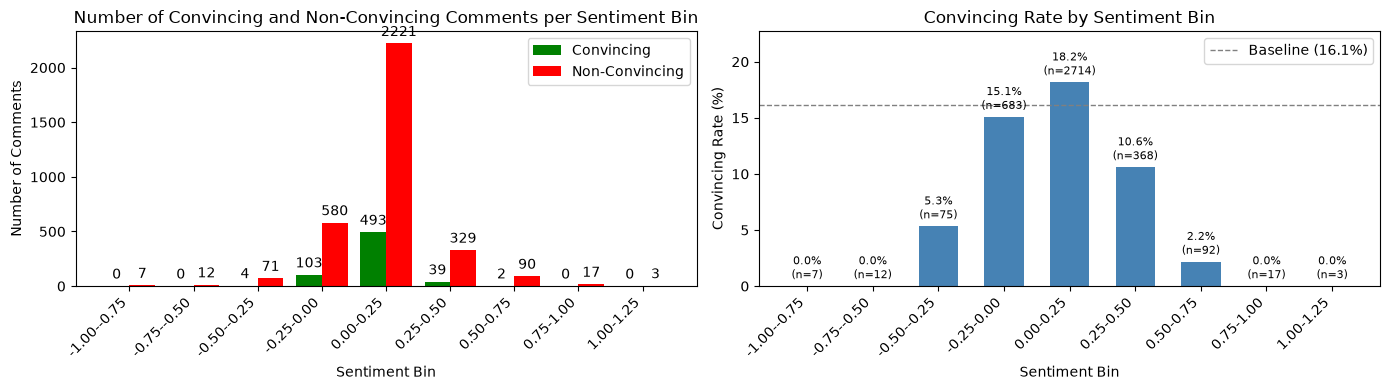

In [7]:
common_functions.plot_feature(comments_df, 'sentiment', 'Sentiment', 0.25, show_counts=True)

In [286]:
def show_example_comments(feature_name='sentiment'):
  # Find 3 comments with minimal sentiment
  min_sentiment_comments = comments_df.nsmallest(3, feature_name)
  for index, row in min_sentiment_comments.iterrows():
      print(f"Minimal Sentiment Comment (Sentiment: {row[feature_name]:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

  # Find 3 comments with maximal sentiment
  max_sentiment_comments = comments_df.nlargest(3, feature_name)
  for index, row in max_sentiment_comments.iterrows():
      print(f"Maximal Sentiment Comment (Sentiment: {row[feature_name]:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

In [287]:
show_example_comments()

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: If noone can decide what is evil then there's nothing evil about schadenfreude
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: You're looking for r/TrueUnpopularOpinion. Some shocking opinions, but that's the nature of the beast.
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: Thats probably the worst example ever
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: nan
  Final Comment: I wouldn’t have thought of that, but I feel it captures the sentiment perfectly.
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: What would be the alternative?  An anarchosyndicalist commune, with someone taking turns to act as a sort of executive officer of the week?  


  Final Comment: > What would be the alternative? An anarchosyndicalist commune, wit

The TextBlob way of identifying the sentiment is based on scoring each word in the text and taking the average score. This approach is less suitable for texts as long as ours. As we can see in the example texts, the sentiment is not identified very well, so we will try a more sophisticated approach, the VADER module.

In [288]:
comments_df = comments_df.drop(columns=['sentiment'])  # drop the TextBlob attempt entirely - not accurate enough to keep, VADER's sentiment_vader replaces it


### VADER module

In [ ]:
!pip install vaderSentiment

In [96]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

In [97]:
comments_df["sentiment_vader"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment_vader
count,3971.000000,3971.000000
mean,0.161420,0.143829
std,0.367965,0.691212
min,0.000000,-0.999900
25%,0.000000,-0.504300
50%,0.000000,0.238200
75%,0.000000,0.828950
max,1.000000,0.999700


In [20]:
show_example_comments('sentiment_vader')

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: Just wanted to chime in with a tiny part. If your living conditions weren't great, or even good, that doesn't give you the right to take it out on people.

I'm a child of war and as shocking that may sound to someone - it gives zero free passing in court. Having PTSD from it is a different thing, but even in cases where someone with PTSD commits a crime he's still held accountable.

Living in a war zone as a child does affect you, but it's not a free pass for being an ass.
[SEP]
He wasn't just *"walking around angry"*.

He had a bat. 

He waited to *be attacked*.

He was ready to ~~hurt~~ kill *any black man* for something one (maybe!) did.

He did it for a *whole week*.


That's really calculated and not something irrational he did while angry. He was making sure that *when* he kills **random black person** it will be said persons fault and LN would play it as self defence. 

Growing up in a war zone does fuck you up, but th

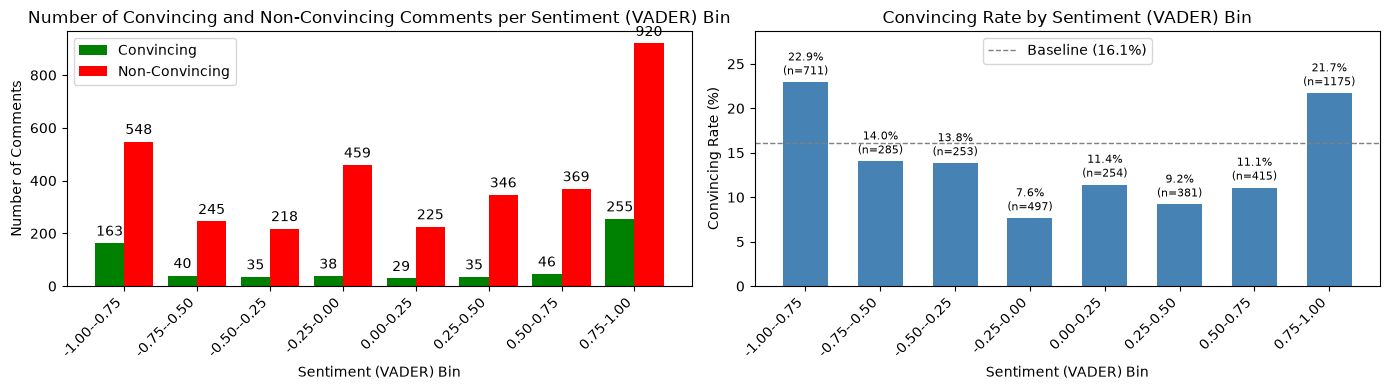

In [9]:
common_functions.plot_feature(comments_df, 'sentiment_vader', 'Sentiment (VADER)', 0.25, show_counts=True)

The rate chart shows a mild U-shape: the convincing rate is elevated at both extremes - 22.9% (n=711) in the most negative bin and 21.7% (n=1,175) in the most positive bin, both clearly above the ~16.1% baseline - while the middle of the range sits below it, dipping as low as 7.6% (n=497) just below neutral and 9.2% (n=381) in the 0.25-0.50 bin.

Reading the count-only chart on the left, the positive end looks like it's mostly non-convincing comments (the tallest red bar in the whole chart) - but that's just because 0.75-1.00 is the single largest bin by volume (n=1,175); its actual rate is above baseline, not below. Raw counts and rates can point in different directions when bin sizes vary this much, which is exactly why the rate chart on the right is the one to read.

Even with a real U-shaped pattern here, we're not happy with it. Looking at the actual examples, VADER is conflating negative *topic* with negative *tone*: the lowest-scored comments are calm, reasoned discussions of dark subjects (racism, police violence, historical injustice) with no rude or hostile language at all, and one of the highest-scored comments is just a dense technical argument about energy technology, not a "pleasant" style. VADER scores on word-level polarity, so words like *racist*, *kill*, or *threat* pull the score down regardless of how respectfully the author is actually writing.

We'll try an LLM-based approach instead, which can reason about the author's tone in context rather than scoring word-by-word.

In [291]:
untrusted_features.append('sentiment_vader')


### LLM-based sentiment (Gemini)

Instead of scoring word-by-word, ask an LLM to rate the author's tone directly, explicitly separating it from the topic being discussed.

In [292]:
genai_client = common_functions.make_gemini_client()
GEMINI_MODEL = common_functions.DEFAULT_GEMINI_MODEL
from google.genai import errors as genai_errors

print(f"Using Gemini model: {GEMINI_MODEL}")

Using Gemini model: gemini-flash-latest


In [293]:
sentiment_llm_prompt_prefix = common_functions.SENTIMENT_LLM_PROMPT_PREFIX
print(sentiment_llm_prompt_prefix)

Rate the sentiment of each of the following numbered texts on a scale from -1 (very negative) to 1 (very positive).

Base your score only on the tone and attitude of the person writing (e.g. hostile, dismissive, or rude vs. friendly, respectful, or warm) - NOT on how negative or positive the topic being discussed is. A calm, respectful discussion of a dark or violent topic should score close to neutral, not negative.

Reply with exactly one line per text, in the format "N: score" (matching the numbers below), and nothing else.

Texts:



In [104]:
comments_df['sentiment_llm'] = None


In [ ]:
import re

def get_sentiment_llm_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = sentiment_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  scores = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)', line)
    if match:
      i, score = int(match.group(1)), float(match.group(2))
      if 0 <= i < len(scores):
        scores[i] = score
  return scores


In [ ]:
BATCH_SIZE = 20

pending_index = comments_df[comments_df['sentiment_llm'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_sentiment_llm_batch([comments_df.loc[i] for i in batch_index])
    for i, score in zip(batch_index, scores):
      comments_df.at[i, 'sentiment_llm'] = score
    comments_df.to_csv('../results/comments_df_sentiment_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [294]:
none_count = comments_df['sentiment_llm'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

comments_df['sentiment_llm'] = pd.to_numeric(comments_df['sentiment_llm'], errors='coerce')
comments_df['sentiment_llm'].describe()


All entries were classified!


count    3971.000000
mean        0.074918
std         0.339024
min        -1.000000
25%        -0.100000
50%         0.100000
75%         0.300000
max         1.000000
Name: sentiment_llm, dtype: float64

In [47]:
show_example_comments('sentiment_llm')

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: I will dance on their graves until I need to piss.
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: Why don’t you go use a mouth-operated shotgun, you literal human appendix
--------------------
Minimal Sentiment Comment (Sentiment: -0.90):
  Thread Text: nan
  Final Comment: HOW DARE YOU ATTACK MY SON RANCID FUCKBURGER WILLIAMS THE 3rd. 
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: nan
  Final Comment: I saved your post it was so good. Hear hear to that!
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: I want to start by expressing how much I respect you for having the balls to engage in this level of self reflection. From my experience, anyone who is willing to examine themselves and question their actions and belief system is showing that they have what it takes to grow and find hap

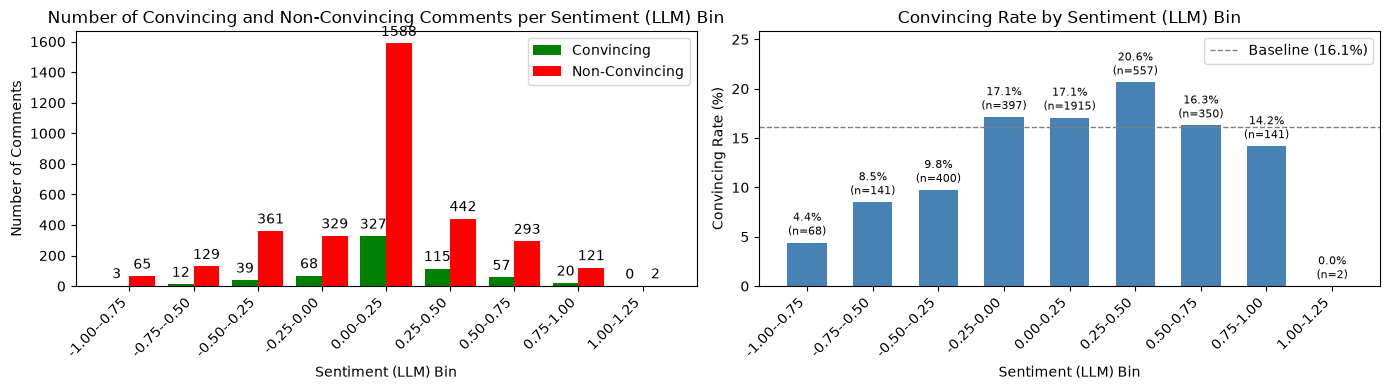

In [10]:
common_functions.plot_feature(comments_df, 'sentiment_llm', 'Sentiment (LLM)', 0.25, show_counts=True)

Looking at the example comments above, this approach succeeds where VADER struggled: the most negative examples are genuinely hostile in tone (open insults, gloating, all-caps anger), and the most positive examples are warm and supportive regardless of how heavy the topic is — including a long, serious response about self-worth that still reads as encouraging rather than negative. The tone/topic separation we were hoping for is working as intended.

The chart tells a different story, though. The `0.00-0.25` bin alone accounts for roughly half the dataset, and across the neutral-to-positive range (`-0.25` and up) the ratio of convincing to non-convincing comments stays close to the dataset's overall ~16% convincing rate, with no visible trend. There's a mild dip in the convincing rate at the very negative end, but those bins hold too few comments to draw a real conclusion from.

Unlike the VADER attempt, the issue here isn't that the metric is unreliable — it's that sentiment tone on its own doesn't appear to separate convincing from non-convincing comments. We'll keep `sentiment_llm` as a feature rather than marking it untrusted, since a weak or non-linear relationship might still be picked up by the model, but we don't expect it to be a strong predictor by itself.

## 6.2 Tone

We would like to create a feature for the tone of the text. The tone can be, for example, logical, passionate, humorous, etc. We'll first try a pre-trained RoBERTa model, then fall back to a Gemini-based approach if the results aren't satisfying.

**GPU note:** the RoBERTa cells below need a GPU to run in reasonable time. If you don't have one locally, run them in [Colab](https://colab.research.google.com/) with a GPU runtime:

1. Upload this notebook to Colab (File → Upload notebook).
2. Set the runtime to GPU (Runtime → Change runtime type → GPU).
3. Upload the checkpoint file saved above (`../results/comments_df_sentiment_checkpoint.csv`) via the Files pane on the left.
4. Run the cell below to load the checkpoint, then continue running the notebook from here.

In [ ]:
import pandas as pd

comments_df = pd.read_csv(f'/content/comments_df_sentiment_checkpoint.csv')
separator_token = "[SEP]"  # marks the boundary between thread text and final comment when concatenated

print(f'Loaded checkpoint: comments_df ({len(comments_df)} rows)')

### RoBERTa based model

In [ ]:
!pip install torch transformers

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

def get_tone(text):
    return classifier(text, truncation=True, padding=True)  # since our texts may be long and Roberta is limited to 512 tokens, we truncate any excessive text

text = get_comment_and_thread(comment_first=True) # the text may be truncated so we put the convincing comment first - it's more important
comments_df["tone"] = text.apply(get_tone)


Now we store the file in Google Drive. Then we can download the file from there and continue locally.




In [ ]:
# store in Google Drive:
try:
    from google.colab import drive
    drive.mount('/content/drive')

    # any path under /content/drive/MyDrive/... is now just a normal filesystem path
    drive_dir = '/content/drive/MyDrive'

    comments_df.to_csv(f'{drive_dir}/comments_df_roberta_checkpoint.csv', index=False)

    print(f'Saved checkpoint to {drive_dir}')
except ImportError:
    print("Not in Colab!")

In [236]:
# Load the checkpoint locally:
comments_df = pd.read_csv('../results/comments_df_roberta_checkpoint.csv')
print("Loaded from checkpoint!")

Loaded from checkpoint!


In [242]:
comments_df['tone']

0       [{'label': 'neutral', 'score': 0.8635463714599...
1       [{'label': 'neutral', 'score': 0.3964949548244...
2         [{'label': 'joy', 'score': 0.5279607772827148}]
3       [{'label': 'neutral', 'score': 0.9494373202323...
4       [{'label': 'neutral', 'score': 0.7024448513984...
                              ...                        
3966    [{'label': 'disgust', 'score': 0.9260729551315...
3967     [{'label': 'fear', 'score': 0.6567504405975342}]
3968    [{'label': 'neutral', 'score': 0.9447934031486...
3969    [{'label': 'neutral', 'score': 0.9226306080818...
3970    [{'label': 'neutral', 'score': 0.5850096940994...
Name: tone, Length: 3971, dtype: str

In [245]:
comments_df['tone'][0]

"[{'label': 'neutral', 'score': 0.8635463714599609}]"

In [246]:
# the tone values are strings that represent lists. we convert them to real lists:
import ast
comments_df['tone'] = comments_df['tone'].apply(ast.literal_eval)
comments_df['tone'][0]

[{'label': 'neutral', 'score': 0.8635463714599609}]

In [247]:
comments_df['tone_label'] = comments_df['tone'].apply(lambda x: x[0]['label'] if isinstance(x, list) and len(x) > 0 else None)

In [296]:
comments_df['tone_label']

0       neutral
1       neutral
2           joy
3       neutral
4       neutral
         ...   
3966    disgust
3967       fear
3968    neutral
3969    neutral
3970    neutral
Name: tone_label, Length: 3971, dtype: str

In [250]:
def show_tone_examples(tone_label):
  for index, row in comments_df[comments_df['tone'].apply(lambda x: isinstance(x, list) and len(x) > 0 and x[0]['label'] == tone_label and x[0]['score'] > 0.85)].iterrows():
    print(f"Example for {tone_label}:")
    print(row['final_comment'])
    print("-" * 20)
    break

In [251]:
show_tone_examples("fear")
show_tone_examples("joy")
show_tone_examples("surprise")


Example for fear:
Another child of narcissists here. I agree that education and training can prevent a lot, but I don't exactly trust adults to correct their behaviors as much as I trust children when they tell me something is wrong. 

On top of parenting courses, covert abuse could be better prevented by including psychology in early curriculum. Covert abuse is so dangerous and damaging because children don't understand what's happening to them until they reach adulthood; where the trauma has started to set in. Start giving children the knowledge and power to escape early.

-Start by teaching young children a course in autonomy and boundaries. (Make sure to involve parents in the homework to promote the lesson across generations)

-Set up better systems so they can self report and be taken seriously. 

-Stop requiring parent's permission for emancipation

I fully support more psychology in basic education.

I hesitate to support passing an evaluation to become a parent, because I fear

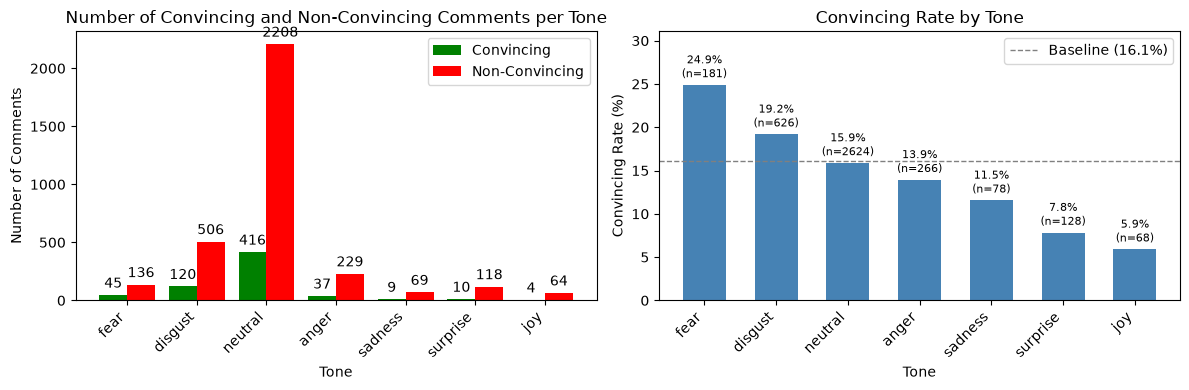

In [11]:
common_functions.plot_category_histogram(comments_df, 'tone_label', 'Tone', show_counts=True)


The distribution above shows the classifier collapsing two-thirds of comments (2,624 of 3,971) into a single 'neutral' bucket, and within that bucket the convincing rate (15.9%) is essentially the same as the overall convincing rate (16.1%) — so a 'neutral' label carries no real signal about persuasion. The other six emotions split more unevenly by convincing rate, from 5.9% for joy up to 24.9% for fear, but each of them is a thin slice of the data (68–626 comments), so those swings could just as easily be noise as a genuine effect.

The examples above back this up: the 'fear' example is a long, structured, multi-point policy argument that doesn't read as fear-driven at all, and the 'surprise' example is sarcastic, rhetorical frustration rather than genuine surprise. The classifier was trained on short, single-emotion statements, and it doesn't seem to transfer well to long, argumentative CMV comments, where emotion words often show up rhetorically rather than as the comment's dominant tone. Between the neutral-heavy, uninformative distribution and these label/content mismatches, we don't trust `tone_label` as a feature and mark it untrusted before trying a different approach with Google AI Studio.

In [298]:
untrusted_features.append('tone_label')

### Google's Gemini

Reusing the Gemini client and model set up in [6.1](#6.1-Sentiment-Analysis).

In [51]:
# let's try with an example text taken randomly from our data set:
test_text = comments_df.iloc[95]['final_comment']
test_text

"If Bernie the lifelong politician can't pass basic cognition and civics tests, then no, he shouldn't be president.   He may be mostly appointing the right people and listening to advisors, but he still has to make tough decisions. \n\nAlthough I believe there already is a cognition test for the president, I remember Trump bragging about passing it"

In [299]:
user_prompt_prefix = common_functions.TONE_LLM_PROMPT_PREFIX
print(user_prompt_prefix)

Analyze the tone of each of the following numbered texts and classify it as one of the following: Logical, Passionate, Humorous, Sarcastic, Neutral, or Other.

Reply with exactly one line per text, in the format "N: label" (matching the numbers below), and nothing else.

Texts:



In [60]:
user_prompt = user_prompt_prefix + f"0:\n{test_text}\n"

response = genai_client.models.generate_content(model=GEMINI_MODEL, contents=user_prompt)
classification = response.text.strip()
print(classification)


0: Logical


In [54]:
comments_df['tone_google'] = None

In [ ]:
import re

def get_tone_from_google_ai_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = user_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise common_functions.BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  classifications = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(classifications):
        classifications[i] = label
  return classifications


In [181]:
BATCH_SIZE = 20

def classify_tone_batch(batch_index):
  try:
    classifications = get_tone_from_google_ai_batch([comments_df.loc[i] for i in batch_index])
    for i, classification in zip(batch_index, classifications):
      comments_df.at[i, 'tone_google'] = classification
  except common_functions.BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      comments_df.at[batch_index[0], 'tone_google'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_tone_batch(batch_index[:mid])
      classify_tone_batch(batch_index[mid:])

pending_index = comments_df[comments_df['tone_google'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_tone_batch(batch_index)
    comments_df.to_csv('../results/comments_df_tone_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [300]:
none_count = comments_df['tone_google'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

All entries were classified!


In [301]:
comments_df['tone_google'].head(20)

0        Logical
1     Passionate
2     Passionate
3        Neutral
4        Logical
5        Neutral
6     Passionate
7        Logical
8        Logical
9     Passionate
10     Sarcastic
11     Sarcastic
12       Logical
13       Logical
14     Sarcastic
15     Sarcastic
16       Logical
17       Logical
18       Neutral
19       Logical
Name: tone_google, dtype: str

In [72]:
def show_tone_examples(tone_label):
  print(f"Example for {tone_label}:")
  print(comments_df[comments_df['tone_google'] == tone_label].iloc[0]['final_comment'])
  print("-" * 20)

show_tone_examples("Humorous")
show_tone_examples("Sarcastic")
show_tone_examples("Passionate")

Example for Humorous:
He tweeted he was running for president. That's it.

Elon Musk, who is basically a shit poster, chimed in and replied to his tweet with his "endorsement"

My guess: It's all about Kanyes next album, which will be available for free on the newest tesla or something silly like that.

I have seen no proof that he's **actually** running. Anyone can tweet that they're running for president.

Will it cause more people to write in his name in the ballots? Yes. But they probably would have wrote in Harambe or SpongeBob instead if it wasn't Kanye.
--------------------
Example for Sarcastic:
Case closed boys pack it up!

We’ve been outsmarted by the billionaires again.

The same group of people that never transact with their billions. It just amasses while they sit there doing nothing. 
Definitely not buying high end goods, or flying private jets, or purchasing property or artwork or buying multimillion dollar cars or receiving dividends or selling stock or hoarding large s

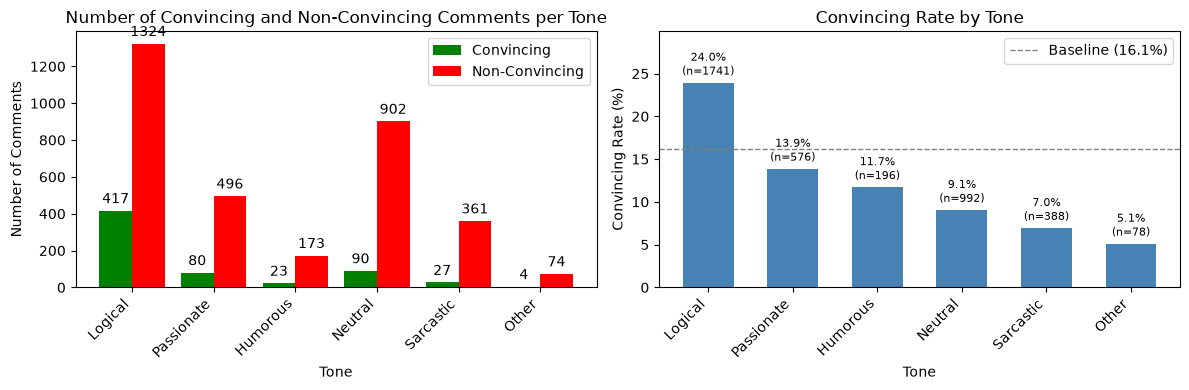

In [12]:
common_functions.plot_category_histogram(comments_df, 'tone_google', 'Tone', show_counts=True)

`Logical` is by far the most common tone (44% of comments), followed by `Neutral` (25%), `Passionate` (14%), `Sarcastic` (10%), `Humorous` (5%), and `Other` (2%). The examples above confirm the labels are doing what we'd expect: the humorous one jokes about Kanye's presidential run, the sarcastic one drips with mock resignation ("Case closed boys pack it up!"), and the passionate one argues forcefully and directly without either of the other two tones' distance.


The convincing rate also varies clearly by tone, unlike what we saw with the plain sentiment score. `Logical` comments convince at 24.0%, well above the dataset's ~16.1% baseline, while `Sarcastic` (7.0%), `Other` (5.1%), and `Neutral` (9.1%) convince well below it; `Passionate` (13.9%) and `Humorous` (11.7%) land close to baseline. This matches intuition — reasoned argument persuades more often than mockery or flat restatement — so we'll keep `tone_google` as a feature.


## 6.3 Style - formal / informal
We would like to create a feature for the style of the text, in other words is it formal or informal text.

For this we will use the model facebook/bart-large-mnli that has been trained on a wide range of general text categories.

We will use this model with zero-shot classification, by defining labels "formal" and "informal" and classify the texts into these categories.

### 6.3.1 bart-large-mnli

**GPU note:** the style classification cells below need a GPU to run in reasonable time. If you don't have one locally, run them in [Colab](https://colab.research.google.com/) with a GPU runtime:

1. Upload this notebook to Colab (File → Upload notebook).
2. Set the runtime to GPU (Runtime → Change runtime type → GPU).
3. Upload the checkpoint file saved above (`../results/comments_df_tone_checkpoint.csv`) via the Files pane on the left.
4. Run the cell below to load the checkpoint, then continue running the notebook from here.

In [ ]:
import pandas as pd

comments_df = pd.read_csv(f'/content/comments_df_tone_checkpoint.csv')

print(f'Loaded checkpoint: comments_df ({len(comments_df)} rows)')

In [ ]:
import torch
from transformers import pipeline

# place the model on GPU when available, and classify comments in batches (below) rather
# than one at a time, to avoid the "pipelines sequentially on GPU" inefficiency warning
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)

candidate_labels = ["formal", "informal"]

In [266]:
def build_style_input(row):
  if not isinstance(row['thread_text'], str):
    return row['final_comment']
  return row['thread_text'] + "\n" + row['final_comment']

In [ ]:
comments_df['style'] = None

We store the file after each batch. If running in colab - we store it in Google Drive. Otherwise, we store it locally.

In [ ]:
# store in Google Drive:
try:
    from google.colab import drive
    drive.mount('/content/drive')

    # any path under /content/drive/MyDrive/... is now just a normal filesystem path
    drive_dir = '/content/drive/MyDrive'
except ImportError:
    print("Not in Colab!")
    drive_dir = '../results'

In [ ]:
BATCH_SIZE = 32

pending_index = comments_df[comments_df['style'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  texts = [build_style_input(comments_df.loc[i]) for i in batch_index]
  try:
    results = classifier(texts, candidate_labels, batch_size=8)
    for i, result in zip(batch_index, results):
      comments_df.at[i, 'style'] = result
    comments_df.to_csv(f'{drive_dir}/comments_df_style_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")

The following cells no longer need GPU, so the results can be downloaded from Google Drive and continue locally.

In [258]:
# Load the checkpoint locally:
comments_df = pd.read_csv('../results/comments_df_style_checkpoint.csv')
print("Loaded from checkpoint!")

Loaded from checkpoint!


In [260]:
import ast

def parse_style(style):
  data = ast.literal_eval(style) if isinstance(style, str) else style
  data.pop('sequence', None)  # drops the full input text, which balloons the saved file size
  return data

comments_df['style'] = comments_df['style'].apply(parse_style)
comments_df['style'].iloc[0]

{'labels': ['informal', 'formal'],
 'scores': [0.886103093624115, 0.1138969212770462]}

In [261]:
def get_style_label(style):
  return style['labels'][style['scores'].index(max(style['scores']))]

get_style_label(comments_df['style'].iloc[0])

'informal'

In [262]:
comments_df['style_label'] = comments_df['style'].apply(get_style_label)

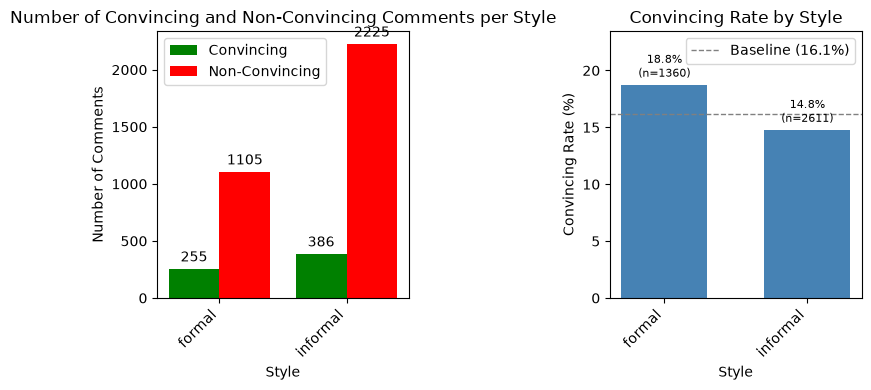

In [23]:
common_functions.plot_category_histogram(comments_df, 'style_label', 'Style', show_counts=True, figsize=(4, 4), panel_gap=0.8)

We see that most of the comments are informal, which makes sense for this type of communication.

In [267]:
def show_style_example(style):
  print(f"Example for {style}:")
  for _, row in comments_df[comments_df['style_label'] == style].iterrows():
    if max(row['style']['scores']) > 0.95:
      print(build_style_input(row))  # the full text the classifier actually scored
      print("-" * 20)
      break

show_style_example("formal")
show_style_example("informal")

Example for formal:
Yup, this is the law where I am.  Employer is required to give notice, or the same amount of pay in lieu of notice.  Most employers choose to give pay as soon-to-be laid off employees tend to be poor employees.

The only exception is if the employee is fired for cause -- but the burden is on the employer to show cause if challenged.
--------------------
Example for informal:
Then the money continues to circulate, funding subsequent years, it doesn’t just disappear. Not saying this is what should be done or how, but this idea that there’s just not enough money in the world to tax the wealth of billionaires or that it wouldn’t make a difference is like a half-finished thought.
[SEP]
I’m working in the court system this year and I can’t disagree that there’s a lot of waste, but I think we should be striving for improvement instead of letting “starve the beast” be a successful tactic
We’ve spent trillions on wars not just because of bureaucracy and red tape, but because

The examples above suggest the classifier's formal/informal labels aren't reliable — texts labeled "formal" with high confidence still often read as informal. This makes sense given that zero-shot classification with a general-purpose NLI model (`bart-large-mnli`) is a weaker signal here than a model fine-tuned for register/formality detection, so scores on informal, slang-heavy Reddit text should be taken with a grain of salt. For this reason we keep `style` and `style_label` as features but mark `style_label` as untrusted, the same treatment we gave `tone_label`.

In [304]:
untrusted_features.append('style_label')

### 6.3.2 Google's Gemini

The BART-large-MNLI zero-shot labels above aren't reliable. Rather than drop the style feature entirely, let's try the same LLM-based approach that replaced `tone_label` with `tone_google`: ask Gemini to judge formality directly, in context, instead of scoring against fixed NLI hypotheses.

Reusing the Gemini client and model set up in [6.1](#6.1-Sentiment-Analysis).

In [313]:
style_llm_prompt_prefix = common_functions.STYLE_LLM_PROMPT_PREFIX
print(style_llm_prompt_prefix)

Analyze the writing register of each of the following numbered texts and classify it as one of the following: Formal, Informal.

Reply with exactly one line per text, in the format "N: label" (matching the numbers below), and nothing else.

Texts:



In [314]:
comments_df['style_google'] = None

In [327]:
import re

def get_style_from_google_ai_batch(rows):
  texts = [build_style_input(row) for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = style_llm_prompt_prefix + numbered_texts
  response = common_functions.generate_content_with_retry(genai_client, GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise common_functions.BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  labels = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(labels):
        labels[i] = label
  return labels

In [ ]:
import time

BATCH_SIZE = 20
SECONDS_BETWEEN_BATCHES = 7  # keep requests-per-minute under the free tier's RPM cap; raise this if you still see 429s

def classify_style_batch(batch_index):
  try:
    labels = get_style_from_google_ai_batch([comments_df.loc[i] for i in batch_index])
    for i, label in zip(batch_index, labels):
      comments_df.at[i, 'style_google'] = label
  except common_functions.BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      comments_df.at[batch_index[0], 'style_google'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_style_batch(batch_index[:mid])
      classify_style_batch(batch_index[mid:])

pending_index = comments_df[comments_df['style_google'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_style_batch(batch_index)
    comments_df.to_csv('../results/comments_df_style_google_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    if 'RESOURCE_EXHAUSTED' in str(e) and 'prepay' in str(e).lower():
      print("prepay credits are depleted, not a transient error - top up billing or swap in a fresh free-tier API key. stopping.")
    else:
      print("this looks like a daily quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets (RPD resets at midnight Pacific time).")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")
  time.sleep(SECONDS_BETWEEN_BATCHES)


In [364]:
none_count = comments_df['style_google'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

All entries were classified!


In [366]:
def show_style_google_example(style_label_value):
  print(f"Example for {style_label_value}:")
  print(build_style_input(comments_df[comments_df['style_google'] == style_label_value].iloc[0]))
  print("-" * 20)

show_style_google_example("Formal")
show_style_google_example("Informal")

Example for Formal:
Yes, the top marginal tax rate is [much higher in Japan -- and most other countries in the world, for that matter.](https://taxfoundation.org/taxing-high-income-2019/)

If Bloomberg is shopping for lower tax rates his options are largely countries like Slovakia and Bulgaria.
--------------------
Example for Informal:
> But, as long as Corporate taxes are a thing you have the money being taxed as profit for the company and then immediately taxed a second time as income for the shareholder. 

TIL. Never understood the justification for this before.

If shares are viewed as you "sharing" in the profit of a company, this kind of justification makes sense. I suppose the issue comes from the fact that, in practice, if a furniture company has $X, and then buys $X worth of lumber and then makes $2X off of the furniture, then buys $2X worth of lumber, they end up paying no taxes due to the $2X being entirely business expenses. Despite this, their potential to make money has 

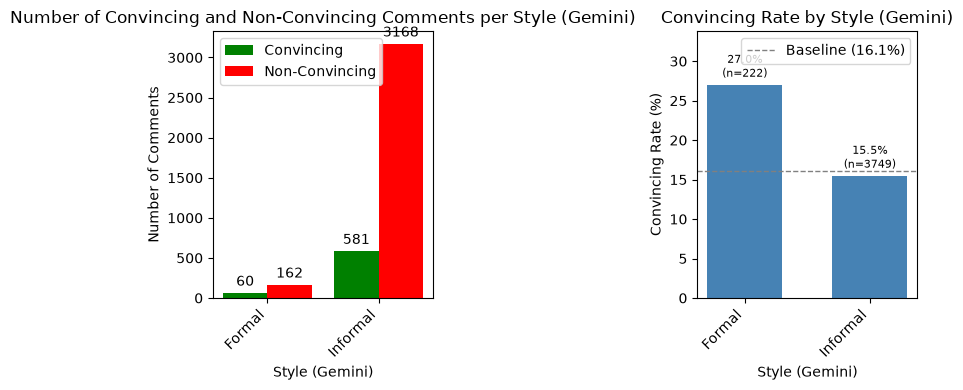

In [28]:
common_functions.plot_category_histogram(comments_df, 'style_google', 'Style (Gemini)', show_counts=True, figsize=(4, 4), panel_gap=1.2)

The distribution is heavily skewed toward informal: 3,749 comments (94.4%) are labeled `Informal` vs. only 222 (5.6%) `Formal`, consistent with Reddit's generally casual register. The examples fit the labels well — the `Formal` example cites a source and reads like a policy note, while the `Informal` example uses casual asides ("TIL", "Huh. Interesting.") and a conversational, reply-by-reply structure — a clear improvement over the BART-large-MNLI labels above, where a text that read as informal was still scored "formal" with high confidence.

The convincing rate also tracks the label meaningfully: `Formal` convinces at 27.0% (n=222), about 1.7x the 16.1% baseline, while `Informal` sits just below baseline at 15.5% (n=3749). The direction fits intuition — well-sourced, measured writing tends to land better as an argument than casual, off-the-cuff replies — though the `Formal` gap rests on a much smaller sample than `Informal`, so its magnitude should be read cautiously. We'll keep `style_google` as a feature.

## Checkpoint — for `03.2`

Sections 6.1–6.3 are done. `03.2` continues from here to add 6.4–6.9 before handing off to `03.3`.

In [344]:
comments_df.to_csv('../results/03_1_comments_df.csv', index=False)

import json
with open('../results/03_1_untrusted_features.json', 'w') as f:
    json.dump(untrusted_features, f, indent=2)

print(f'Saved 03_1_comments_df.csv ({len(comments_df)} rows), 03_1_untrusted_features.json: {untrusted_features}')

Saved 03_1_comments_df.csv (3971 rows), 03_1_untrusted_features.json: ['sentiment_vader', 'tone_label', 'style_label']
